<a href="https://colab.research.google.com/github/imperorrp/discrete-generative-models-proj-1/blob/main/notebooks/runs/text_xattn_cifar_run1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text conditioning by cross-attention on CIFAR-100

Baseline 3 of 3: the condition enters the network as text, through attention, with **no
guidance at sampling time**. Trains a base diffusion model (or loads one), freezes it,
adds one cross-attention block at the bottleneck, trains only that block, samples.

**Paper:** Chen, Yu, Ge, Yao, Xie, Wu, Wang, Kwok, Luo, Lu, Li.
*PixArt-α: Fast Training of Diffusion Transformer for Photorealistic Text-to-Image
Synthesis.* ICLR 2024. [arXiv:2310.00426](https://arxiv.org/abs/2310.00426)

**Official code exists** and was read:
[PixArt-alpha/PixArt-alpha](https://github.com/PixArt-alpha/PixArt-alpha),
`MultiHeadCrossAttention` in `PixArt_blocks.py` and its zero-init in `PixArt.py`.
`src/guidance/baselines/cross_attention.py` re-expresses that block in plain PyTorch for
a conv U-Net; its header lists what was kept and what changed.

**What this arm tests, and why the label path is off by default.** The TC-LoRA run showed
that a text embedding of a class name adds nothing on top of the class label — the
adapter moved 11% and changed nothing (`docs/findings.md`). So here the backbone runs
with the **null label** and the text is the *only* route by which the model learns the
class. If cross-attention conditions at all, it has to show up. Set `label_path = True`
to reproduce the TC-LoRA setting instead.

Run top to bottom. On Colab set **Runtime > Change runtime type > GPU** first.

In [1]:
# Colab bootstrap. Run once.
import importlib.util, subprocess, sys, os

for pkg in ("transformers", "datasets"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

if importlib.util.find_spec("guidance") is None:
    if not os.path.exists("discrete-generative-models-proj-1"):
        subprocess.run(["git", "clone", "-q",
                        "https://github.com/imperorrp/discrete-generative-models-proj-1.git"],
                       check=True)
    sys.path.insert(0, "discrete-generative-models-proj-1/src")

import torch
from guidance.baselines.cross_attention import TextConditioned

def _git_sha():
    for d in ("discrete-generative-models-proj-1", "."):
        try:
            return subprocess.check_output(["git", "-C", d, "rev-parse", "--short", "HEAD"],
                                           text=True, stderr=subprocess.DEVNULL).strip()
        except Exception:
            pass
    return "unknown"

GIT_SHA = _git_sha()
print("code version:", GIT_SHA)
print("device:", "cuda" if torch.cuda.is_available()
      else "CPU  <-- Runtime > Change runtime type > GPU")

code version: 429ead4
device: cuda


## Data source

Nothing to do here. The loader tries a local copy first (`./cifar`, `/content/cifar`,
`/content/drive/MyDrive/cifar`, ...), then the HuggingFace CDN. It never touches
`cs.toronto.edu`, which is rate-limited to ~50 kB/s.

## Config

In [2]:
import math, time, json
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

@dataclass
class Cfg:
    seed: int = 10                 # training randomness
    split_seed: int = 10           # validation split. Fixed on purpose: change `seed` for a
                                   # multi-seed run WITHOUT moving training images into val.
    batch_size: int = 64
    base_epochs: int = 30
    xattn_epochs: int = 15
    lr_base: float = 2e-4
    lr_xattn: float = 1e-4
    K: int = 1000                  # diffusion training steps
    sample_steps: int = 50         # DDIM steps
    heads: int = 4
    attach: str = "mid"            # U-Net stage whose output the text conditions
    label_path: bool = False       # False: backbone sees the null label; text is the only condition
    reuse_base: bool = True        # load base.pt if present instead of retraining
    limit: int = 0                 # >0 truncates the training set, for smoke tests

cfg = Cfg()
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(cfg.seed); np.random.seed(cfg.seed)
print(DEV, asdict(cfg))

cuda {'seed': 10, 'split_seed': 10, 'batch_size': 64, 'base_epochs': 30, 'xattn_epochs': 15, 'lr_base': 0.0002, 'lr_xattn': 0.0001, 'K': 1000, 'sample_steps': 50, 'heads': 4, 'attach': 'mid', 'label_path': False, 'reuse_base': True, 'limit': 0}


## Data

From `src/guidance/data/cifar.py`. Pixels normalised to `[-1, 1]`; 50 images per class
held out for validation with a seeded per-class shuffle.

In [3]:
from guidance.data.cifar import make_loaders

train_loader, val_loader, meta = make_loaders(
    batch_size=cfg.batch_size, seed=cfg.split_seed, limit=cfg.limit)

xb, cb = next(iter(train_loader))
print("x", tuple(xb.shape), f"[{float(xb.min()):.2f}, {float(xb.max()):.2f}]",
      "| cond", tuple(cb.shape))
print("train batches", len(train_loader), "| val batches", len(val_loader))
print("conditions", meta["n_conditions"], "| example text:", meta["cond_text"][0])

no local copy found; fetching from the HuggingFace CDN


README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  119MB            

cifar100/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

cifar100/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.8MB            

cifar100/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

x (64, 3, 32, 32) [-1.00, 1.00] | cond (64,)
train batches 703 | val batches 79
conditions 100 | example text: a photo of a apple


## Frozen text encoder — token embeddings, not a pooled vector

The TC-LoRA arm used CLIP's pooled 512-vector. Cross-attention needs the **per-token**
embeddings and the padding mask: with a single key token the softmax is identically 1 and
the block degenerates into adding a constant. It still conditions, but it cannot select
between words, which is the point of the mechanism.

Falls back to random tokens if CLIP will not load; the manifest records that, and a
fallback run is not a result.

In [4]:
def build_token_embeddings(texts, device):
    '''Returns (tokens (N, L, D), mask (N, L) bool, is_fallback).'''
    try:
        from transformers import CLIPTokenizer, CLIPTextModel, logging as hf_logging
        hf_logging.set_verbosity_error()          # silence the vision_model.* UNEXPECTED report
        name = "openai/clip-vit-base-patch32"
        tok = CLIPTokenizer.from_pretrained(name)
        enc = CLIPTextModel.from_pretrained(name).to(device).eval()
        for p in enc.parameters():
            p.requires_grad_(False)
        b = tok(texts, padding=True, truncation=True, return_tensors="pt")
        with torch.no_grad():
            hidden = enc(**{k: v.to(device) for k, v in b.items()}).last_hidden_state
        return hidden, b["attention_mask"].to(device).bool(), False
    except Exception as e:
        print(f"CLIP unavailable ({type(e).__name__}); using random fallback tokens.")
        g = torch.Generator().manual_seed(0)
        toks = torch.randn(len(texts), 8, 512, generator=g).to(device)
        return toks, torch.ones(len(texts), 8, dtype=torch.bool, device=device), True

TEXT_TOK, TEXT_MASK, IS_FALLBACK = build_token_embeddings(meta["cond_text"], DEV)
TEXT_DIM = TEXT_TOK.shape[-1]
print("token embeddings:", tuple(TEXT_TOK.shape), "| real tokens per prompt:",
      TEXT_MASK.sum(1).tolist()[:5], "... | fallback:", IS_FALLBACK)

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

token embeddings: (100, 9, 512) | real tokens per prompt: [7, 8, 7, 7, 7] ... | fallback: False


## Backbone

In [5]:
def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10_000.0) * torch.arange(half, device=t.device) / half)
    args = t.float()[:, None] * freqs[None, :]
    return torch.cat([args.cos(), args.sin()], dim=-1)


def conv_block(cin, cout, groups=8):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1), nn.GroupNorm(groups, cout), nn.SiLU(),
        nn.Conv2d(cout, cout, 3, padding=1), nn.GroupNorm(groups, cout), nn.SiLU(),
    )


class UNet(nn.Module):
    '''Class-conditional U-Net. The label enters as a per-channel bias after block 1.'''

    def __init__(self, c=64, n_classes=100, tdim=128):
        super().__init__()
        self.tdim, self.null = tdim, n_classes
        self.t_mlp = nn.Sequential(nn.Linear(tdim, c), nn.SiLU(), nn.Linear(c, c))
        self.label = nn.Embedding(n_classes + 1, c)      # +1 = null token
        self.e1, self.e2 = conv_block(3, c), conv_block(c, 2 * c)
        self.mid = conv_block(2 * c, 4 * c)
        self.d2, self.d1 = conv_block(6 * c, 2 * c), conv_block(3 * c, c)
        self.out = nn.Conv2d(c, 3, 1)
        self.pool = nn.MaxPool2d(2)
        nn.init.zeros_(self.out.weight); nn.init.zeros_(self.out.bias)

    def forward(self, x, t, cond_ids=None):
        if cond_ids is None:
            cond_ids = torch.full((x.shape[0],), self.null, device=x.device, dtype=torch.long)
        bias = (self.t_mlp(timestep_embedding(t, self.tdim))
                + self.label(cond_ids))[:, :, None, None]
        s1 = self.e1(x) + bias
        s2 = self.e2(self.pool(s1))
        h = self.mid(self.pool(s2))
        h = self.d2(torch.cat([F.interpolate(h, size=s2.shape[-2:]), s2], 1))
        h = self.d1(torch.cat([F.interpolate(h, size=s1.shape[-2:]), s1], 1))
        return self.out(h)


def make_backbone():
    return UNet(64, meta["n_conditions"])

net = make_backbone().to(DEV)
MID_CHANNELS = 4 * 64                    # output width of the stage named by cfg.attach
print(f"backbone params: {sum(p.numel() for p in net.parameters()):,}")

backbone params: 1,904,707


## Diffusion — cosine schedule, epsilon prediction, DDIM sampler

In [6]:
def cosine_alpha_bar(K, s=0.008, device="cpu"):
    steps = torch.arange(K + 1, dtype=torch.float32, device=device) / K
    f = torch.cos((steps + s) / (1 + s) * math.pi / 2) ** 2
    return (f / f[0])[1:].clamp(1e-5, 0.9999)

ABAR = cosine_alpha_bar(cfg.K, device=DEV)
NULL_ID = meta["n_conditions"]

# At the first DDIM step sqrt(abar) is about 0.003, so x0 = (x - sqrt(1-abar) eps)/sqrt(abar)
# divides by a tiny number and any error in eps is amplified ~300x. Without clamping the
# samples blow up. Pixels are normalised to [-1, 1], so the clamp is 1.
CLIP_X0 = 1.0


def add_noise(x0, gen=None):
    '''gen: pass a seeded torch.Generator to get the same (k, eps) every call.'''
    n = x0.shape[0]
    k = torch.randint(0, cfg.K, (n,), device=x0.device, generator=gen)
    eps = torch.randn(x0.shape, device=x0.device, generator=gen)
    ab = ABAR[k].view(n, *([1] * (x0.dim() - 1)))
    return ab.sqrt() * x0 + (1 - ab).sqrt() * eps, k, eps


def drop_labels(y, p_drop=0.1):
    '''Condition dropout creates the null branch that guidance needs later.'''
    keep = torch.rand(y.shape[0], device=y.device) >= p_drop
    return torch.where(keep, y, torch.full_like(y, NULL_ID))


@torch.no_grad()
def ddim_sample(eps_fn, n, shape, steps, clip_x0=None, n_snapshots=0, x_init=None):
    '''eps_fn(x, t) -> predicted noise. Deterministic DDIM.

    x_init: pass the same starting noise to two calls for a paired comparison.
    n_snapshots > 0 also returns evenly spaced intermediate states.
    '''
    clip_x0 = CLIP_X0 if clip_x0 is None else clip_x0
    idx = torch.linspace(cfg.K - 1, 0, steps).long().to(DEV)
    keep = set(torch.linspace(0, steps - 1, max(n_snapshots, 1)).long().tolist())
    x = torch.randn(n, *shape, device=DEV) if x_init is None else x_init.clone()
    snaps = [x.cpu().clone()] if n_snapshots else []
    for i, k in enumerate(idx):
        t = (k.float() / cfg.K).repeat(n)
        eps = eps_fn(x, t)
        ab = ABAR[k]
        ab_prev = ABAR[idx[i + 1]] if i + 1 < len(idx) else torch.ones_like(ab)
        x0 = ((x - (1 - ab).sqrt() * eps) / ab.sqrt()).clamp(-clip_x0, clip_x0)
        x = ab_prev.sqrt() * x0 + (1 - ab_prev).sqrt() * eps
        if n_snapshots and i in keep:
            snaps.append(x.cpu().clone())
    return (x, snaps) if n_snapshots else x

## Base model — train, or load `base.pt` if it is already here

The base is identical to the TC-LoRA arm's. If you have `base.pt` from that run, upload it
to the session and this cell loads it instead of spending eight minutes retraining. Both
arms then share exactly the same frozen weights, which is what makes the comparison a
controlled one.

Training applies 10% label dropout; validation is fully conditional on fixed noise. See the
TC-LoRA notebook for why those differ.

In [7]:
VAL_SEED = cfg.seed + 999


def run_epochs(model, params, n_epochs, lr, tag, train_fn, val_fn, ckpt):
    '''Trains with train_fn, validates with val_fn on fixed noise, keeps the best checkpoint.'''
    opt = torch.optim.AdamW(params, lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(n_epochs, 1))
    hist, best, best_ep = [], float("inf"), 0
    for ep in range(1, n_epochs + 1):
        model.train(); tot = num = 0; t0 = time.time()
        for x, y in train_loader:
            x, y = x.to(DEV), y.to(DEV)
            loss = train_fn(x, y)
            opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()
            tot += loss.item() * x.shape[0]; num += x.shape[0]
        sched.step()

        val = validate(model, val_fn)
        is_best = val < best
        if is_best:
            best, best_ep = val, ep
            torch.save({"state": model.state_dict(), "epoch": ep, "val": val}, ckpt)
        hist.append({"epoch": ep, "train": tot / num, "val": val, "best": is_best})
        print(f"{tag} epoch {ep:3d}  train {tot/num:.4f}  val {val:.4f}"
              f"{'  *best' if is_best else ''}  ({time.time()-t0:.0f}s)")
    print(f"{tag}: best val {best:.4f} at epoch {best_ep}, saved to {ckpt}")
    return hist


@torch.no_grad()
def validate(model, val_fn):
    '''Same examples, same timesteps, same noise on every call -- for any model.'''
    model.eval()
    gen = torch.Generator(device=DEV).manual_seed(VAL_SEED)
    tot = num = 0
    for x, y in val_loader:
        x, y = x.to(DEV), y.to(DEV)
        tot += val_fn(x, y, gen).item() * x.shape[0]; num += x.shape[0]
    return tot / num


def base_train(x, y):
    xk, k, eps = add_noise(x)
    return F.mse_loss(net(xk, k.float() / cfg.K, drop_labels(y)), eps)


def base_val(x, y, gen):
    xk, k, eps = add_noise(x, gen)
    return F.mse_loss(net(xk, k.float() / cfg.K, y), eps)     # no dropout


# What a base.pt must agree on before it can be reused. A checkpoint trained under a
# different split would put its own training images into this run's validation set.
CKPT_META = {"split_seed": cfg.split_seed, "n_conditions": meta["n_conditions"],
             "shape": list(meta["shape"]), "K": cfg.K, "schedule": "cosine",
             "backbone_params": sum(p.numel() for p in net.parameters())}

if cfg.reuse_base and os.path.exists("base.pt"):
    ck = torch.load("base.pt", map_location=DEV)
    saved = ck.get("meta")
    if saved is None:
        print("WARNING: base.pt carries no setup metadata (older run); split and schedule "
              "cannot be verified. Treat any comparison against it with care.")
    else:
        mismatch = {k: (saved.get(k), v) for k, v in CKPT_META.items() if saved.get(k) != v}
        assert not mismatch, f"base.pt was trained under a different setup: {mismatch}"
    net.load_state_dict(ck["state"])
    base_hist = [{"epoch": ck["epoch"], "train": float("nan"), "val": ck["val"], "best": True}]
    print(f"loaded base.pt (epoch {ck['epoch']}, val {ck['val']:.4f}); skipping base training")
else:
    base_hist = run_epochs(net, list(net.parameters()), cfg.base_epochs, cfg.lr_base,
                           "base", base_train, base_val, "base.pt")
    ck = torch.load("base.pt", map_location=DEV); ck["meta"] = CKPT_META; torch.save(ck, "base.pt")

base epoch   1  train 0.2000  val 0.0851  *best  (16s)
base epoch   2  train 0.0807  val 0.0771  *best  (15s)
base epoch   3  train 0.0752  val 0.0736  *best  (15s)
base epoch   4  train 0.0711  val 0.0709  *best  (15s)
base epoch   5  train 0.0705  val 0.0696  *best  (15s)
base epoch   6  train 0.0685  val 0.0681  *best  (15s)
base epoch   7  train 0.0676  val 0.0673  *best  (15s)
base epoch   8  train 0.0676  val 0.0668  *best  (15s)
base epoch   9  train 0.0665  val 0.0668  (15s)
base epoch  10  train 0.0663  val 0.0656  *best  (15s)
base epoch  11  train 0.0645  val 0.0651  *best  (17s)
base epoch  12  train 0.0647  val 0.0648  *best  (15s)
base epoch  13  train 0.0642  val 0.0644  *best  (16s)
base epoch  14  train 0.0645  val 0.0643  *best  (15s)
base epoch  15  train 0.0642  val 0.0638  *best  (15s)
base epoch  16  train 0.0630  val 0.0637  *best  (15s)
base epoch  17  train 0.0636  val 0.0632  *best  (15s)
base epoch  18  train 0.0634  val 0.0634  (15s)
base epoch  19  train 0.

## Attach cross-attention and train only that block

The backbone is frozen. One `TextCrossAttention` block is inserted after the stage named
by `cfg.attach`; it flattens the feature map into query tokens, attends to the text tokens,
and adds the result back. Its output projection is zero-initialised (PixArt-α's own
initialisation), so the first assertion — adapted model equals base at step zero — is what
makes this a controlled comparison.

`COND(y)` is the label the backbone sees: the true label if `cfg.label_path`, otherwise the
null token. With the null token, the text is the model's only knowledge of the class.

In [8]:
ckpt = torch.load("base.pt", map_location=DEV)
base_frozen = make_backbone().to(DEV)
base_frozen.load_state_dict(ckpt["state"])
base_frozen.eval()

def COND(y):
    return y if cfg.label_path else torch.full_like(y, NULL_ID)

probe_x, probe_y = xb[:4].to(DEV), cb[:4].to(DEV)
probe_t = torch.rand(4, device=DEV)
with torch.no_grad():
    ref = base_frozen(probe_x, probe_t, COND(probe_y)).clone()

xa = TextConditioned(base_frozen, attach=cfg.attach, channels=MID_CHANNELS,
                     text_dim=TEXT_DIM, heads=cfg.heads).to(DEV)

with torch.no_grad():
    got = xa(probe_x, probe_t, TEXT_TOK[probe_y], TEXT_MASK[probe_y], cond_ids=COND(probe_y))
assert torch.allclose(got, ref, atol=1e-5), (got - ref).abs().max().item()
print("no-op at init confirmed")

assert all(".attn." in n for n, p in xa.named_parameters() if p.requires_grad)
# The adapter now lives INSIDE base_frozen, so count frozen params by requires_grad, not
# by module membership -- otherwise the adapter is counted on both sides.
N_FROZEN = sum(p.numel() for p in base_frozen.parameters() if not p.requires_grad)
print(f"trainable: {xa.n_trainable():,} params, all in the cross-attention block")
print(f"frozen:    {N_FROZEN:,} params")
print(f"label path: {'ON (true label)' if cfg.label_path else 'OFF (null label; text only)'}")

no-op at init confirmed
trainable: 394,240 params, all in the cross-attention block
frozen:    1,904,707 params
label path: OFF (null label; text only)


In [9]:
def xa_train(x, y):
    xk, k, eps = add_noise(x)
    return F.mse_loss(xa(xk, k.float() / cfg.K, TEXT_TOK[y], TEXT_MASK[y], cond_ids=COND(y)), eps)


def xa_val(x, y, gen):
    xk, k, eps = add_noise(x, gen)
    return F.mse_loss(xa(xk, k.float() / cfg.K, TEXT_TOK[y], TEXT_MASK[y], cond_ids=COND(y)), eps)


xa_hist = run_epochs(xa, [p for p in xa.parameters() if p.requires_grad],
                     cfg.xattn_epochs, cfg.lr_xattn, "xattn", xa_train, xa_val, "xattn.pt")

best = torch.load("xattn.pt", map_location=DEV)["state"]
xa.load_state_dict(best)
xa.eval()
print("restored best cross-attention block")

xattn epoch   1  train 0.0614  val 0.0620  *best  (16s)
xattn epoch   2  train 0.0622  val 0.0620  *best  (15s)
xattn epoch   3  train 0.0612  val 0.0619  *best  (16s)
xattn epoch   4  train 0.0627  val 0.0619  *best  (16s)
xattn epoch   5  train 0.0623  val 0.0619  *best  (15s)
xattn epoch   6  train 0.0617  val 0.0619  *best  (15s)
xattn epoch   7  train 0.0612  val 0.0619  *best  (15s)
xattn epoch   8  train 0.0618  val 0.0619  *best  (15s)
xattn epoch   9  train 0.0618  val 0.0619  *best  (15s)
xattn epoch  10  train 0.0620  val 0.0619  *best  (15s)
xattn epoch  11  train 0.0618  val 0.0619  *best  (16s)
xattn epoch  12  train 0.0616  val 0.0618  *best  (15s)
xattn epoch  13  train 0.0615  val 0.0618  *best  (15s)
xattn epoch  14  train 0.0613  val 0.0618  *best  (15s)
xattn epoch  15  train 0.0624  val 0.0618  *best  (16s)
xattn: best val 0.0618 at epoch 15, saved to xattn.pt
restored best cross-attention block


## The comparable numbers, and the diagnostic that matters

Three validation MSEs on identical examples, timesteps and noise:

- **base, same label path** — what the text-conditioned model starts from. With the label
  path off this is the *unconditional* model.
- **base, true label** — a reference: what knowing the class is worth when it comes in
  through the label embedding.
- **cross-attention** — the arm under test.

And the diagnostic: validation with the **wrong text**. Labels are shifted by a fixed
offset, so every example gets a genuinely different class, and the shift consumes no
random state, so correct- and wrong-text passes see byte-identical noise and timesteps.
(A within-batch permutation would fail both tests here: the validation set is ordered by
class, so most permuted labels would land on the same class, and drawing the permutation
from the noise generator would desynchronise the two passes.) Averaged over three offsets.

Read the result as *average loss sensitivity to the text*. A small aggregate difference
is a finding, not proof the text is ignored — it could matter only at some noise levels,
or only for the samples, which the next cells check separately. A null here is
reportable. Base-vs-adapter differences include the adaptation itself; correct-vs-wrong
text *within* the adapted model is what isolates the text.

In [10]:
def frozen_val_same_path(x, y, gen):
    xk, k, eps = add_noise(x, gen)
    return F.mse_loss(base_frozen(xk, k.float() / cfg.K, COND(y)), eps)


def frozen_val_label(x, y, gen):
    xk, k, eps = add_noise(x, gen)
    return F.mse_loss(base_frozen(xk, k.float() / cfg.K, y), eps)


def xa_val_wrong_text(offset):
    '''Wrong text via a fixed label shift: always a different class, never touches gen.'''
    def fn(x, y, gen):
        xk, k, eps = add_noise(x, gen)
        y_wrong = (y + offset) % meta["n_conditions"]
        return F.mse_loss(xa(xk, k.float() / cfg.K, TEXT_TOK[y_wrong], TEXT_MASK[y_wrong],
                             cond_ids=COND(y)), eps)
    return fn


WRONG_OFFSETS = (1, 37, 73)

VAL_BASE_SAME = validate(base_frozen, frozen_val_same_path)
VAL_BASE_LABEL = validate(base_frozen, frozen_val_label)
VAL_XA = validate(xa, xa_val)
VAL_XA_WRONG_EACH = [validate(xa, xa_val_wrong_text(o)) for o in WRONG_OFFSETS]
VAL_XA_WRONG = sum(VAL_XA_WRONG_EACH) / len(VAL_XA_WRONG_EACH)

print(f"base, same label path as xattn : {VAL_BASE_SAME:.4f}")
print(f"base, true label (reference)   : {VAL_BASE_LABEL:.4f}")
print(f"xattn, correct text            : {VAL_XA:.4f}   ({(VAL_BASE_SAME - VAL_XA) / VAL_BASE_SAME:+.1%} vs base)")
print(f"xattn, wrong text (mean of {len(WRONG_OFFSETS)}) : {VAL_XA_WRONG:.4f}   "
      f"per offset {[round(v, 4) for v in VAL_XA_WRONG_EACH]}")
TEXT_EFFECT = (VAL_XA_WRONG - VAL_XA) / VAL_XA
print()
print(f"text effect (wrong - correct) / correct = {TEXT_EFFECT:+.2%}")
if abs(TEXT_EFFECT) < 0.005:
    print("little average loss sensitivity to the text at this training budget. "
          "Check the per-noise-level breakdown and the sample comparison below before concluding.")

base, same label path as xattn : 0.0621
base, true label (reference)   : 0.0620
xattn, correct text            : 0.0618   (+0.5% vs base)
xattn, wrong text (mean of 3) : 0.0624   per offset [0.0624, 0.0624, 0.0624]

text effect (wrong - correct) / correct = +0.92%


## Text sensitivity by noise level

The aggregate number above averages over the whole trajectory. Text may matter only late
(fine detail) or only early (layout). This bins the correct-vs-wrong loss gap by noise
level on the same fixed noise.

In [11]:
@torch.no_grad()
def loss_by_noise_level(offset, n_bins=5):
    xa.eval()
    gen = torch.Generator(device=DEV).manual_seed(VAL_SEED)
    edges = torch.linspace(0, cfg.K, n_bins + 1, device=DEV)
    sums = torch.zeros(n_bins, 2, device=DEV); counts = torch.zeros(n_bins, device=DEV)
    for x, y in val_loader:
        x, y = x.to(DEV), y.to(DEV)
        xk, k, eps = add_noise(x, gen)
        t = k.float() / cfg.K
        yw = (y + offset) % meta["n_conditions"]
        e_ok = ((xa(xk, t, TEXT_TOK[y], TEXT_MASK[y], cond_ids=COND(y)) - eps) ** 2).flatten(1).mean(1)
        e_wr = ((xa(xk, t, TEXT_TOK[yw], TEXT_MASK[yw], cond_ids=COND(y)) - eps) ** 2).flatten(1).mean(1)
        b = torch.bucketize(k.float(), edges[1:-1])
        sums.index_add_(0, b, torch.stack([e_ok, e_wr], 1)); counts.index_add_(0, b, torch.ones_like(b, dtype=torch.float))
    return edges.cpu(), (sums / counts[:, None]).cpu()

edges, per_bin = loss_by_noise_level(WRONG_OFFSETS[0])
print(f"{'noise level (k)':>18} {'correct':>9} {'wrong':>9} {'gap':>8}")
TEXT_EFFECT_BY_BIN = []
for i in range(len(per_bin)):
    ok, wr = per_bin[i].tolist()
    TEXT_EFFECT_BY_BIN.append((wr - ok) / ok)
    print(f"{int(edges[i]):>7}-{int(edges[i+1]):<9} {ok:>9.4f} {wr:>9.4f} {(wr-ok)/ok:>+8.2%}")

   noise level (k)   correct     wrong      gap
      0-200          0.1969    0.1977   +0.41%
    200-400          0.0620    0.0627   +1.19%
    400-600          0.0328    0.0334   +1.89%
    600-800          0.0158    0.0163   +2.98%
    800-1000         0.0044    0.0046   +4.58%


## Training curves

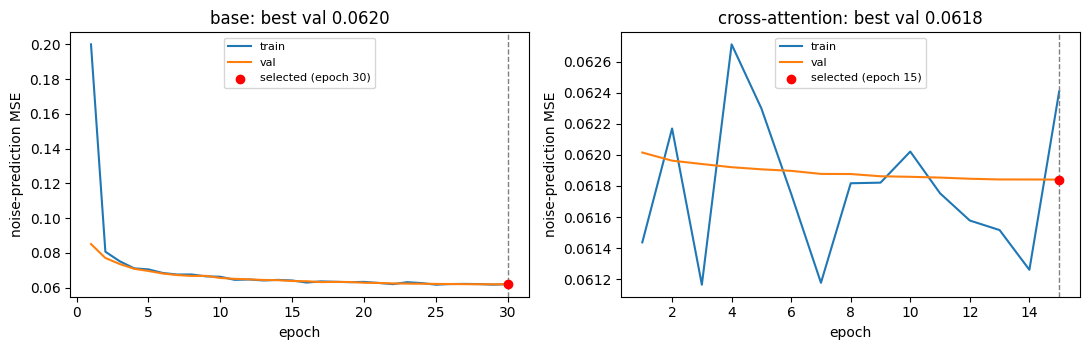

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, (name, hist) in zip(ax, [("base", base_hist), ("cross-attention", xa_hist)]):
    ep = [h["epoch"] for h in hist]
    if len(hist) > 1:
        a.plot(ep, [h["train"] for h in hist], label="train")
    a.plot(ep, [h["val"] for h in hist], label="val", marker="o" if len(hist) == 1 else None)
    bst = min(hist, key=lambda h: h["val"])
    a.axvline(bst["epoch"], ls="--", c="grey", lw=1)
    a.scatter([bst["epoch"]], [bst["val"]], c="red", zorder=5,
              label=f"selected (epoch {bst['epoch']})")
    a.set_title(f"{name}: best val {bst['val']:.4f}")
    a.set_xlabel("epoch"); a.set_ylabel("noise-prediction MSE"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Samples — same starting noise, three conditions

Row 1: the base model, same label path as the arm under test. Row 2: cross-attention with
the **correct** description. Row 3: cross-attention with a **wrong** description (labels
shifted by one). All three start from the same noise, so any difference is the text.

sampled: (8, 3, 32, 32) | NFE per sample: 50 | paired: same X0 for all rows


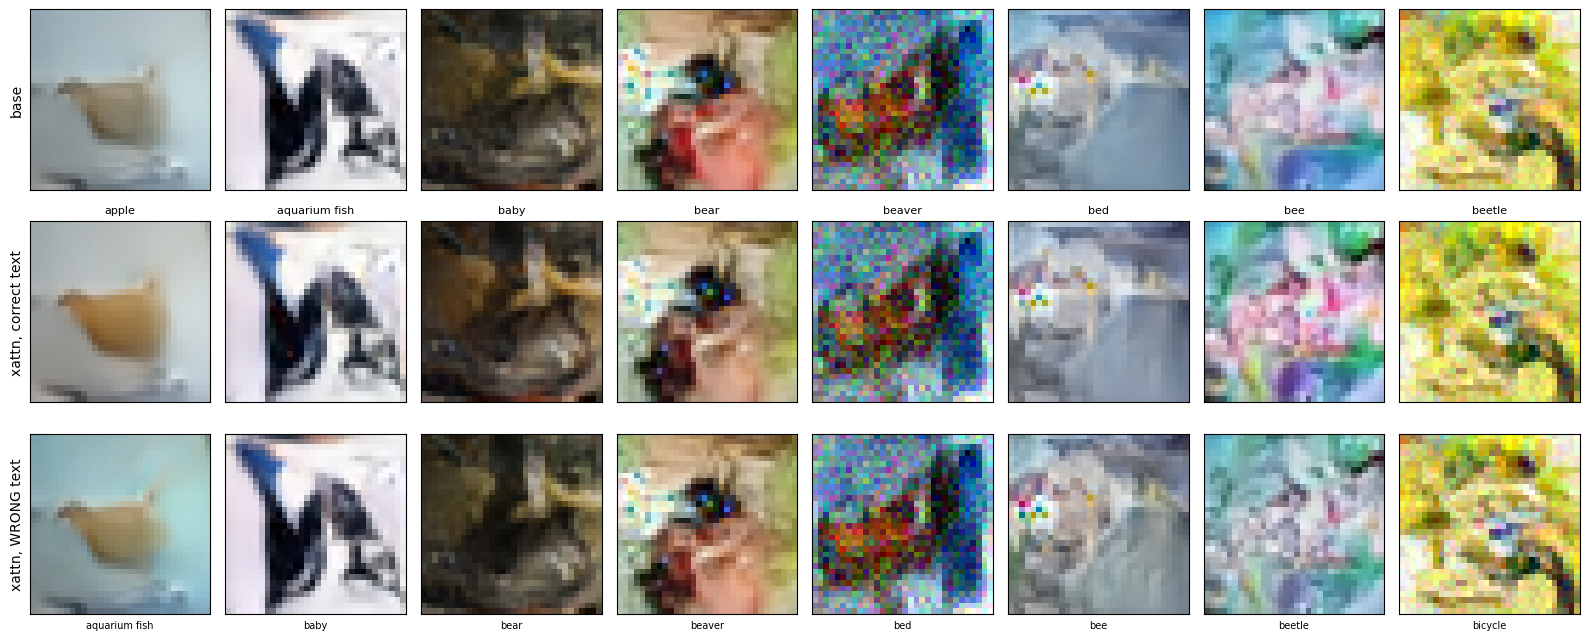

mean relative difference between correct-text and wrong-text samples: 19.9%


In [13]:
N = 8
y_eval = torch.arange(N, device=DEV) % meta["n_conditions"]
y_wrong = (y_eval + 1) % meta["n_conditions"]
g = torch.Generator(device=DEV).manual_seed(cfg.seed + 1)
X0 = torch.randn(N, *meta["shape"], device=DEV, generator=g)

base_s = ddim_sample(lambda x, t: base_frozen(x, t, COND(y_eval)), N, meta["shape"],
                     cfg.sample_steps, x_init=X0)
xa_s = ddim_sample(lambda x, t: xa(x, t, TEXT_TOK[y_eval], TEXT_MASK[y_eval], cond_ids=COND(y_eval)),
                   N, meta["shape"], cfg.sample_steps, x_init=X0)
xa_wrong = ddim_sample(lambda x, t: xa(x, t, TEXT_TOK[y_wrong], TEXT_MASK[y_wrong], cond_ids=COND(y_eval)),
                       N, meta["shape"], cfg.sample_steps, x_init=X0)
print("sampled:", tuple(base_s.shape), "| NFE per sample:", cfg.sample_steps,
      "| paired: same X0 for all rows")

def short(i):
    return meta["cond_text"][int(i)].replace("a photo of a ", "")

fig, axes = plt.subplots(3, N, figsize=(2 * N, 6.6))
rows = [("base", base_s, y_eval), ("xattn, correct text", xa_s, y_eval),
        ("xattn, WRONG text", xa_wrong, y_wrong)]
for r, (name, s, ys) in enumerate(rows):
    for j in range(N):
        axes[r, j].imshow(((s[j].cpu() + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy())
        axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
        if r == 1:
            axes[r, j].set_title(short(ys[j]), fontsize=8)
        if r == 2:
            axes[r, j].set_xlabel(short(ys[j]), fontsize=7)
    axes[r, 0].set_ylabel(name, fontsize=10)
plt.tight_layout(); plt.show()

SAMPLE_TEXT_DIFF = ((xa_s - xa_wrong).flatten(1).norm(dim=1) / xa_s.flatten(1).norm(dim=1)).mean().item()
print(f"mean relative difference between correct-text and wrong-text samples: {SAMPLE_TEXT_DIFF:.1%}")

## Denoising trajectory

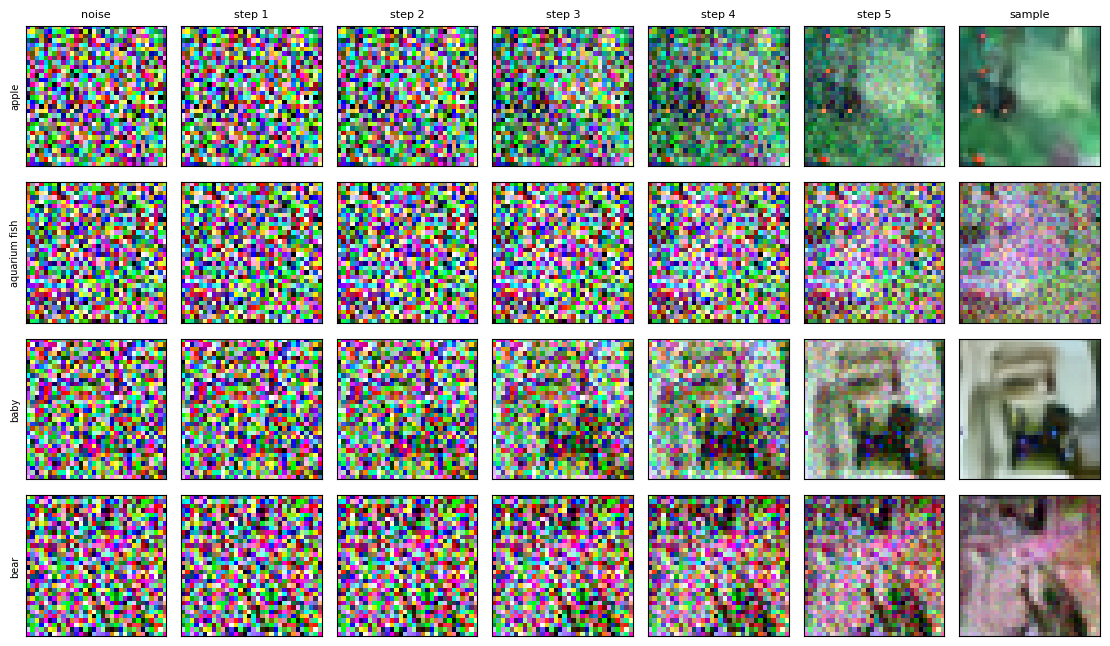

In [14]:
traj_y = y_eval[:4]
_, snaps = ddim_sample(lambda x, t: xa(x, t, TEXT_TOK[traj_y], TEXT_MASK[traj_y], cond_ids=COND(traj_y)),
                       4, meta["shape"], cfg.sample_steps, n_snapshots=6)

fig, axes = plt.subplots(4, len(snaps), figsize=(1.6 * len(snaps), 6.6))
for r in range(4):
    for c, s in enumerate(snaps):
        axes[r, c].imshow(((s[r] + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy())
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0:
            axes[r, c].set_title("noise" if c == 0 else
                                 ("sample" if c == len(snaps) - 1 else f"step {c}"), fontsize=8)
    axes[r, 0].set_ylabel(short(traj_y[r]), fontsize=7)
plt.tight_layout(); plt.show()

## FID (optional, needs a GPU)

Set `n_fid = 10000` for a reportable number. Real images are the 5000-image validation
split; record both counts next to the number.

In [15]:
n_fid = 10000          # set to 10000 for a reportable number; 0 skips this cell

FID_SCORES = {}

if n_fid:
    import importlib.util, subprocess, sys
    for pkg, mod in [("torchmetrics", "torchmetrics"), ("torch-fidelity", "torch_fidelity")]:
        if importlib.util.find_spec(mod) is None:
            print(f"installing {pkg} ...")
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

    from torchmetrics.image.fid import FrechetInceptionDistance

    def to_uint8(x):
        return ((x.clamp(-1, 1) + 1) * 127.5).round().to(torch.uint8)

    def sample_for(which, y):
        if which == "base":
            return ddim_sample(lambda x, t: base_frozen(x, t, COND(y)),
                               len(y), meta["shape"], cfg.sample_steps)
        return ddim_sample(lambda x, t: xa(x, t, TEXT_TOK[y], TEXT_MASK[y], cond_ids=COND(y)),
                           len(y), meta["shape"], cfg.sample_steps)

    for which in ("base", "xattn"):
        fid = FrechetInceptionDistance(feature=2048, normalize=False).to(DEV)
        n_real = 0
        for x, _ in val_loader:
            fid.update(to_uint8(x.to(DEV)), real=True)
            n_real += len(x)
        torch.manual_seed(cfg.seed)
        for start in range(0, n_fid, 100):
            y = torch.arange(start, min(start + 100, n_fid), device=DEV) % meta["n_conditions"]
            fid.update(to_uint8(sample_for(which, y)), real=False)
        FID_SCORES[f"{which}_fid"] = float(fid.compute())
        FID_SCORES["fid_n_real"] = n_real
        FID_SCORES["fid_n_generated"] = n_fid
        print(f"{which} FID {FID_SCORES[f'{which}_fid']:.2f}   "
              f"(real {n_real}, generated {n_fid}, NFE {cfg.sample_steps})")

    if min(FID_SCORES["fid_n_real"], n_fid) < 10000:
        print()
        print("NOTE: FID is biased upward below ~10k samples. Report both counts.")
else:
    print("FID skipped (n_fid = 0)")

installing torchmetrics ...
installing torch-fidelity ...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 192MB/s]


base FID 78.28   (real 5000, generated 10000, NFE 50)
xattn FID 75.67   (real 5000, generated 10000, NFE 50)

NOTE: FID is biased upward below ~10k samples. Report both counts.


## Manifest

In [16]:
report = {
    "method": "text conditioning by cross-attention (PixArt-alpha block, arXiv:2310.00426)",
    "modality": "images",
    "code_version": GIT_SHA,
    "config": asdict(cfg),
    "label_path": cfg.label_path,
    "val_matched_base_same_path": VAL_BASE_SAME,
    "val_matched_base_true_label": VAL_BASE_LABEL,
    "val_matched_xattn": VAL_XA,
    "val_matched_xattn_wrong_text": VAL_XA_WRONG,
    "val_matched_xattn_wrong_text_per_offset": dict(zip(map(str, WRONG_OFFSETS), VAL_XA_WRONG_EACH)),
    "text_effect_rel": TEXT_EFFECT,
    "text_effect_rel_by_noise_bin": TEXT_EFFECT_BY_BIN,
    "sample_text_diff_rel": SAMPLE_TEXT_DIFF,
    "base_best_val_during_training": min(h["val"] for h in base_hist),
    "xattn_best_val_during_training": min(h["val"] for h in xa_hist),
    "trainable_xattn": xa.n_trainable(),
    "frozen_backbone": N_FROZEN,
    "checkpoint_meta": CKPT_META,
    "attach": cfg.attach,
    "nfe": cfg.sample_steps,
    "clip_fallback": IS_FALLBACK,
    "device": str(DEV),
}
report.update(globals().get("FID_SCORES", {}))
print(json.dumps(report, indent=2))
with open("manifest_xattn_images.json", "w") as f:
    json.dump(report, f, indent=2)

{
  "method": "text conditioning by cross-attention (PixArt-alpha block, arXiv:2310.00426)",
  "modality": "images",
  "code_version": "429ead4",
  "config": {
    "seed": 10,
    "split_seed": 10,
    "batch_size": 64,
    "base_epochs": 30,
    "xattn_epochs": 15,
    "lr_base": 0.0002,
    "lr_xattn": 0.0001,
    "K": 1000,
    "sample_steps": 50,
    "heads": 4,
    "attach": "mid",
    "label_path": false,
    "reuse_base": true,
    "limit": 0
  },
  "label_path": false,
  "val_matched_base_same_path": 0.06213443333506584,
  "val_matched_base_true_label": 0.06195813426375389,
  "val_matched_xattn": 0.06184101243019104,
  "val_matched_xattn_wrong_text": 0.06240966827273369,
  "val_matched_xattn_wrong_text_per_offset": {
    "1": 0.06240350710749626,
    "37": 0.06240128358602524,
    "73": 0.062424214124679564
  },
  "text_effect_rel": 0.009195448460430248,
  "text_effect_rel_by_noise_bin": [
    0.004059200438091233,
    0.011888762162211202,
    0.018899723371058764,
    0.02976

## Before reporting any of this

- [ ] `clip_fallback: false` in the manifest
- [ ] `text_effect_rel` reported with its sign and the per-noise-level breakdown; a small
      or null effect is a reportable result, not a reason to withhold the row
- [ ] FID with `n_fid = 10000`; FID measures image quality, not whether the text was used
- [ ] Three seeds (`seed`), mean +/- std, with `split_seed` held fixed
- [ ] `label_path` stated next to every number; the two settings are different experiments
- [ ] Described as **a frozen U-Net with a PixArt-α-inspired residual cross-attention
      adapter** — CLIP not T5, one block not every block, attention-only training, no CFG
      — not as PixArt-α reproduced